# Time-varying Example

This notebook analyses noise with a time-varying spectral density. 

In [ ]:
! pip install -q --upgrade "LogPSplinePSD" "multimethod>=1.12,<2"

## Imports and data generation

In [24]:
import os

os.environ.setdefault("XLA_FLAGS", "--xla_force_host_platform_device_count=1")

import jax
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

from log_psplines import (
    LogPSpline,
    PowerSplineConfig,
    SplineBasis,
    TimeSeries,
    fit,
    moving_periodogram,
    scattered_moving_periodogram,
)
from log_psplines.example_datasets.ls2_data import LS2Data
from log_psplines.preprocessing.wdm import wdm_periodogram

## Simualte LS2 data
ls2_data = LS2Data(n_samples=512 * 8, fs=64.0, seed=42)
ls2_data.plot(fname="ls2_data_analysis.png")


## Data seen by each likelihood

Both transforms turn the same series into squared coefficients that feed the
spline fit directly -- they are not smoothed or converted to a PSD
themselves. WDM fills every retained time/frequency cell; the moving
periodogram visits one frequency rung per window in a zig-zag path, so its
raw ordinates are scattered rather than gridded.


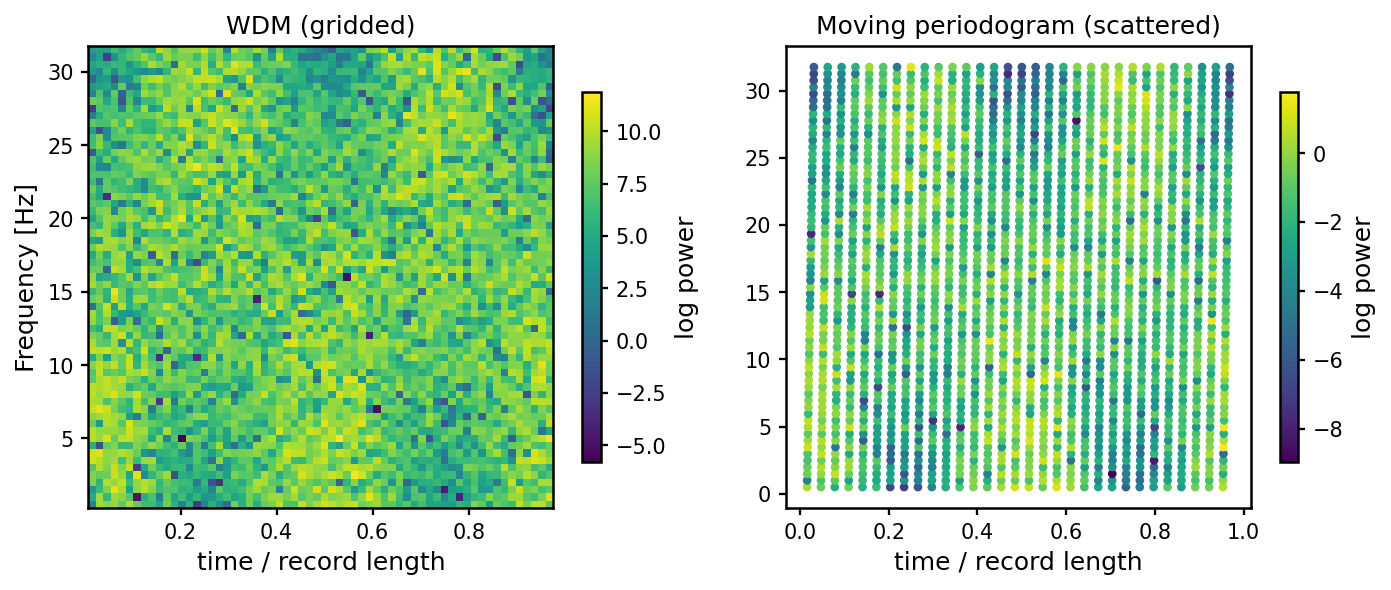

In [25]:
series = TimeSeries(data=ls2_data.data[:, 0], t=ls2_data.time)

# nt must divide n_samples with nt and n_samples/nt both even. WDM's frequency
# count is fixed at n_samples/nt, so nt=n_samples//64 keeps a block length of
# 64 samples (and hence ~64 frequency bins) regardless of n_samples -- this is
# the setting empirically found to give WDM/moving-periodogram RMSE and 90%
# coverage in the same ballpark (see the simulation study at the end).
wdm_data = wdm_periodogram(series, nt=ls2_data.n_samples // 64)

# m sets both the moving-periodogram's frequency count and window width; m=64
# matches WDM's fixed ~64 frequency bins above, and thin=2 keeps enough
# time blocks to resolve the process's time variation.
mp_data = moving_periodogram(ls2_data.data[:, 0], dt=1.0 / ls2_data.fs, m=64, thin=2)
mp_scatter = scattered_moving_periodogram(ls2_data.data[:, 0], dt=1.0 / ls2_data.fs, m=64, thin=2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
mesh = axes[0].pcolormesh(
    wdm_data.time, wdm_data.frequency, np.log(wdm_data.power).T, shading="auto"
)
axes[0].set(title="WDM (gridded)", xlabel="time / record length", ylabel="Frequency [Hz]")
fig.colorbar(mesh, ax=axes[0], label="log power", shrink=0.8)

sc = axes[1].scatter(
    mp_scatter.time, mp_scatter.frequency, c=np.log(mp_scatter.power), s=10
)
axes[1].set(title="Moving periodogram (scattered)", xlabel="time / record length")
fig.colorbar(sc, ax=axes[1], label="log power", shrink=0.8)
plt.show()


## Run analysis with WDM likelihood


In [26]:
wdm_model = LogPSpline(
    frequency=SplineBasis.from_grid(
        wdm_data.frequency / wdm_data.frequency[-1], 8
    ),
    time=SplineBasis.from_grid(wdm_data.time, 8),
)
wdm_result = fit(
    wdm_data,

    PowerSplineConfig(n_warmup=250, n_samples=300, seed=1),

    model=wdm_model,)

sample: 100%|██████████| 550/550 [00:02<00:00, 196.71it/s, 31 steps of size 1.44e-01. acc. prob=0.94] 


## Run analysis with moving-periodogram likelihood

In [27]:
mp_model = LogPSpline(
    frequency=SplineBasis.from_grid(
        mp_data.frequency / mp_data.frequency[-1], 8
    ),
    time=SplineBasis.from_grid(mp_data.time, 8),
)
mp_result = fit(
    mp_data,
    PowerSplineConfig(n_warmup=250, n_samples=300, seed=2),

    model=mp_model,
)

sample: 100%|██████████| 550/550 [00:01<00:00, 306.76it/s, 31 steps of size 1.53e-01. acc. prob=0.92]


## Compare outputs

WDM/moving-periodogram posteriors are in each transform's own
coefficient-variance units, only *proportional* (not equal) to the analytic
PSD. Fit that constant per method (the median log-ratio to the truth) before
plotting or computing residuals -- otherwise every plot and residual below
would be dominated by an arbitrary units offset instead of genuine shape
error.


In [28]:
true_wdm = ls2_data.get_true_psd(time_grid=wdm_result.time, freq_grid=wdm_data.frequency)
true_mp = ls2_data.get_true_psd(time_grid=mp_result.time, freq_grid=mp_data.frequency)

wdm_median = np.median(wdm_result.psd, axis=(0, 1))
mp_median = np.median(mp_result.psd, axis=(0, 1))

# log-ratio residuals: log(posterior draw) - log(truth), flattened over chain/draw/time/freq
wdm_resid = (np.log(wdm_result.psd) - np.log(true_wdm)[None, None]).ravel()
mp_resid = (np.log(mp_result.psd) - np.log(true_mp)[None, None]).ravel()

# The constant depends on each transform's own normalization convention;
# estimate it as the median log-residual, then judge shape error from the
# *spread* of the residuals left after removing it.
wdm_offset = np.median(wdm_resid)
mp_offset = np.median(mp_resid)

n_chains, n_draws, n_time, n_freq = wdm_result.psd.shape
print(f"WDM posterior: {n_chains} chain(s) x {n_draws} draws, grid {n_time}(time) x {n_freq}(freq) "
      f"-> {n_chains * n_draws} posterior samples per grid cell")
n_chains_mp, n_draws_mp, n_time_mp, n_freq_mp = mp_result.psd.shape
print(f"MP  posterior: {n_chains_mp} chain(s) x {n_draws_mp} draws, grid {n_time_mp}(time) x {n_freq_mp}(freq) "
      f"-> {n_chains_mp * n_draws_mp} posterior samples per grid cell")
print(f"\nWDM median log-offset: {wdm_offset:.3f}  (scale factor {np.exp(wdm_offset):.1f}, "
      f"c.f. n_samples={ls2_data.n_samples})")
print(f"MP  median log-offset: {mp_offset:.3f}  (scale factor {np.exp(mp_offset):.3f}, "
      f"c.f. 1/(2*pi)={1 / (2 * np.pi):.3f})")
print(f"WDM residual std after removing the constant offset: {(wdm_resid - wdm_offset).std():.3f}")
print(f"MP  residual std after removing the constant offset: {(mp_resid - mp_offset).std():.3f}")


def _ci_coverage(psd_draws: np.ndarray, true_psd: np.ndarray, log_offset: float) -> float:
    """Fraction of (time, freq) cells where truth falls in the 90% posterior CI."""
    scaled = psd_draws / np.exp(log_offset)
    lower = np.quantile(scaled, 0.05, axis=(0, 1))
    upper = np.quantile(scaled, 0.95, axis=(0, 1))
    return float(np.mean((true_psd >= lower) & (true_psd <= upper)))


wdm_coverage = _ci_coverage(wdm_result.psd, true_wdm, wdm_offset)
mp_coverage = _ci_coverage(mp_result.psd, true_mp, mp_offset)
print(f"\nWDM 90% CI coverage (after constant rescale): {wdm_coverage:.1%}")
print(f"MP  90% CI coverage (after constant rescale): {mp_coverage:.1%}")


WDM posterior: 1 chain(s) x 300 draws, grid 62(time) x 63(freq) -> 300 posterior samples per grid cell
MP  posterior: 1 chain(s) x 300 draws, grid 31(time) x 64(freq) -> 300 posterior samples per grid cell

WDM median log-offset: 8.341  (scale factor 4193.1, c.f. n_samples=4096)
MP  median log-offset: -1.808  (scale factor 0.164, c.f. 1/(2*pi)=0.159)
WDM residual std after removing the constant offset: 0.319
MP  residual std after removing the constant offset: 0.330

WDM 90% CI coverage (after constant rescale): 86.1%
MP  90% CI coverage (after constant rescale): 84.7%


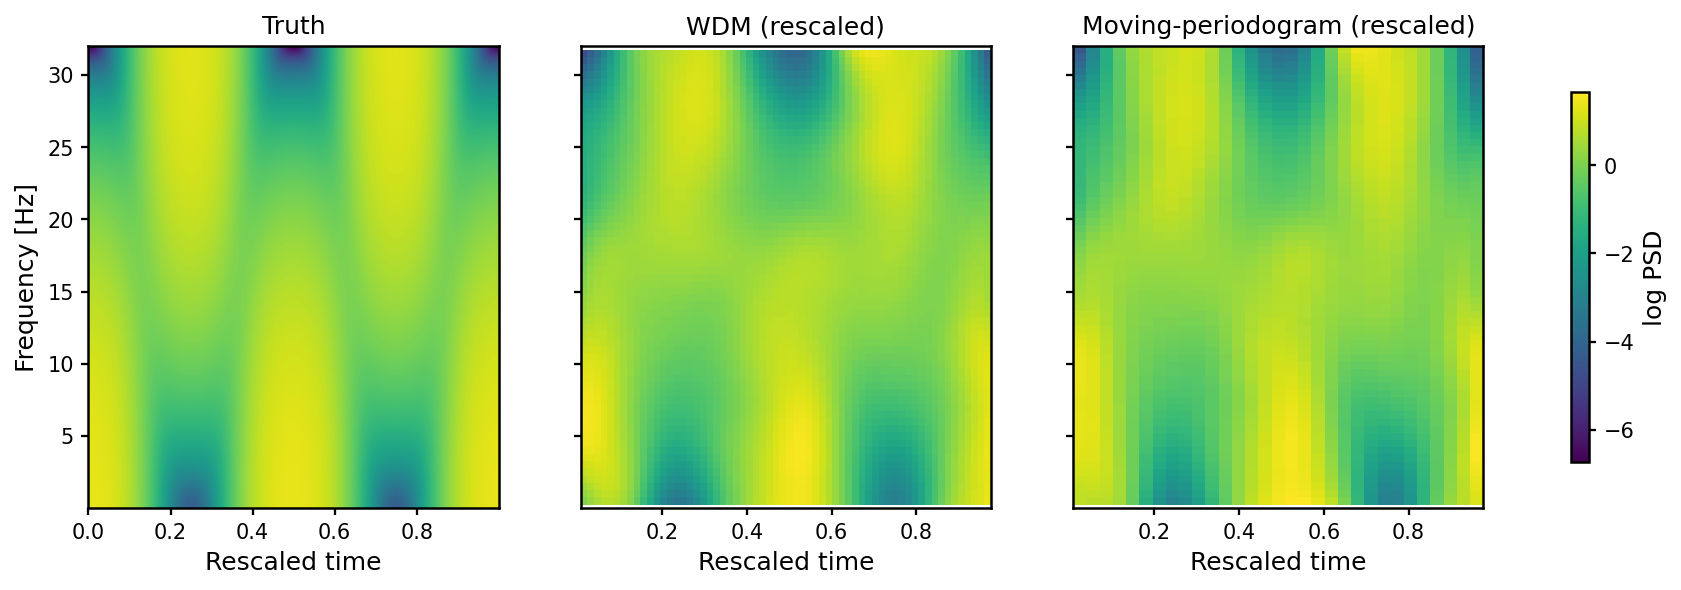

In [32]:
# WDM/MP rescaled by their fitted constant offset so all three panels share
# one color scale -- this is the only PSD comparison worth plotting.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
rescaled_panels = [
    ("Truth", ls2_data.rescaled_time, ls2_data.freq, ls2_data.get_true_psd()),
    ("WDM (rescaled)", wdm_result.time, wdm_data.frequency, wdm_median / np.exp(wdm_offset)),
    ("Moving-periodogram (rescaled)", mp_result.time, mp_data.frequency, mp_median / np.exp(mp_offset)),
]
vmin = np.log(min(p[3].min() for p in rescaled_panels))
vmax = np.log(max(p[3].max() for p in rescaled_panels))
for ax, (title, t, f, psd) in zip(axes, rescaled_panels):
    mesh = ax.pcolormesh(t, f, np.log(psd).T, shading="auto", vmin=vmin, vmax=vmax)
    ax.set(title=title, xlabel="Rescaled time")
axes[0].set_ylabel("Frequency [Hz]")
fig.colorbar(mesh, ax=axes, label="log PSD", shrink=0.8)
plt.show()


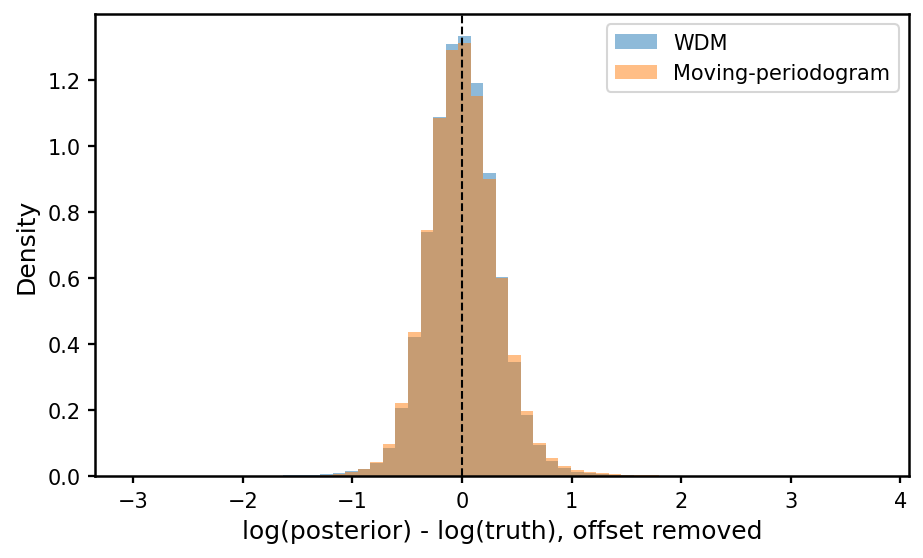

In [33]:
# Same log-ratio residuals as above, but with each method's constant units
# offset removed -- this isolates genuine shape error, centered near zero.
fig, ax = plt.subplots(figsize=(7, 4))
wdm_resid_scaled = wdm_resid - wdm_offset
mp_resid_scaled = mp_resid - mp_offset
bins = np.linspace(
    min(wdm_resid_scaled.min(), mp_resid_scaled.min()),
    max(wdm_resid_scaled.max(), mp_resid_scaled.max()),
    60,
)
ax.hist(wdm_resid_scaled, bins=bins, alpha=0.5, label="WDM", density=True)
ax.hist(mp_resid_scaled, bins=bins, alpha=0.5, label="Moving-periodogram", density=True)
ax.axvline(0.0, color="k", linestyle="--", linewidth=1)
ax.set(xlabel="log(posterior) - log(truth), offset removed", ylabel="Density")
ax.legend()
plt.show()


## Simulation study: scaling with $n$

Repeat the WDM and moving-periodogram fits over a range of series lengths
`n`, using the same resolution-matching rule as above (WDM block length
fixed at 64 samples via `nt = n // 64`; moving periodogram `m=64, thin=2`).
For each `n` we record:

- **MSE** of the log posterior-median PSD vs. the log analytic truth (after
  removing each method's constant units offset),
- **90% credible-interval coverage**,
- **90% CI width** (in log units),
- **wall time** for the fit.

This mirrors the usual WDM-vs-moving-periodogram benchmark, but on the LS2
time-varying process instead of a stationary one.


In [34]:
import time


def _summarize_fit(result, true_psd, wall_time):
    """MSE/coverage/CI-width for a fit, after removing the constant units offset."""
    resid = (np.log(result.psd) - np.log(true_psd)[None, None]).ravel()
    offset = np.median(resid)
    mse = float(np.mean((resid - offset) ** 2))
    scaled = result.psd / np.exp(offset)
    lower = np.quantile(scaled, 0.05, axis=(0, 1))
    upper = np.quantile(scaled, 0.95, axis=(0, 1))
    coverage = float(np.mean((true_psd >= lower) & (true_psd <= upper)))
    ci_width = float(np.mean(np.log(upper) - np.log(lower)))
    return {"mse": mse, "coverage": coverage, "ci_width": ci_width, "wall_time": wall_time}


def analyze_wdm(n_samples: int, *, seed: int, n_warmup: int, n_mcmc_samples: int) -> dict:
    data = LS2Data(n_samples=n_samples, fs=64.0, seed=seed)
    series = TimeSeries(data=data.data[:, 0], t=data.time)
    wdm = wdm_periodogram(series, nt=n_samples // 64)
    model = LogPSpline(
        frequency=SplineBasis.from_grid(wdm.frequency / wdm.frequency[-1], 8),
        time=SplineBasis.from_grid(wdm.time, 8),
    )
    t0 = time.perf_counter()
    result = fit(
        wdm, PowerSplineConfig(n_warmup=n_warmup, n_samples=n_mcmc_samples, seed=seed), model=model
    )
    wall_time = time.perf_counter() - t0
    true_psd = data.get_true_psd(time_grid=result.time, freq_grid=wdm.frequency)
    return _summarize_fit(result, true_psd, wall_time)


def analyze_mp(n_samples: int, *, seed: int, n_warmup: int, n_mcmc_samples: int) -> dict:
    data = LS2Data(n_samples=n_samples, fs=64.0, seed=seed)
    mp = moving_periodogram(data.data[:, 0], dt=1.0 / data.fs, m=64, thin=2)
    model = LogPSpline(
        frequency=SplineBasis.from_grid(mp.frequency / mp.frequency[-1], 8),
        time=SplineBasis.from_grid(mp.time, 8),
    )
    t0 = time.perf_counter()
    result = fit(
        mp, PowerSplineConfig(n_warmup=n_warmup, n_samples=n_mcmc_samples, seed=seed + 1), model=model
    )
    wall_time = time.perf_counter() - t0
    true_psd = data.get_true_psd(time_grid=result.time, freq_grid=mp.frequency)
    return _summarize_fit(result, true_psd, wall_time)


n_values = [1024, 2048, 4096, 8192, 16384]
sweep_records = []
for n in n_values:
    for method, analyze in (("WDM", analyze_wdm), ("Moving periodogram", analyze_mp)):
        stats = analyze(n, seed=42, n_warmup=250, n_mcmc_samples=300)
        stats.update(n=n, method=method)
        sweep_records.append(stats)
        print(
            f"{method:20s} n={n:6d}  MSE={stats['mse']:.3f}  "
            f"coverage={stats['coverage']:.2f}  CI width={stats['ci_width']:.2f}  "
            f"wall={stats['wall_time']:.1f}s"
        )



sample: 100%|██████████| 550/550 [00:01<00:00, 519.39it/s, 15 steps of size 2.60e-01. acc. prob=0.89] 


WDM                  n=  1024  MSE=0.503  coverage=0.76  CI width=1.24  wall=1.1s


sample: 100%|██████████| 550/550 [00:01<00:00, 486.83it/s, 15 steps of size 2.45e-01. acc. prob=0.88] 


Moving periodogram   n=  1024  MSE=0.428  coverage=0.77  CI width=1.11  wall=1.2s


sample: 100%|██████████| 550/550 [00:01<00:00, 309.12it/s, 31 steps of size 1.75e-01. acc. prob=0.93]


...

Moving periodogram   n=  8192  MSE=0.069  coverage=0.81  CI width=0.49  wall=2.8s


sample: 100%|██████████| 550/550 [00:08<00:00, 66.24it/s, 63 steps of size 7.03e-02. acc. prob=0.93]  


WDM                  n= 16384  MSE=0.038  coverage=0.75  CI width=0.36  wall=8.3s


sample: 100%|██████████| 550/550 [00:04<00:00, 118.00it/s, 63 steps of size 6.85e-02. acc. prob=0.94] 


Moving periodogram   n= 16384  MSE=0.047  coverage=0.75  CI width=0.36  wall=4.7s


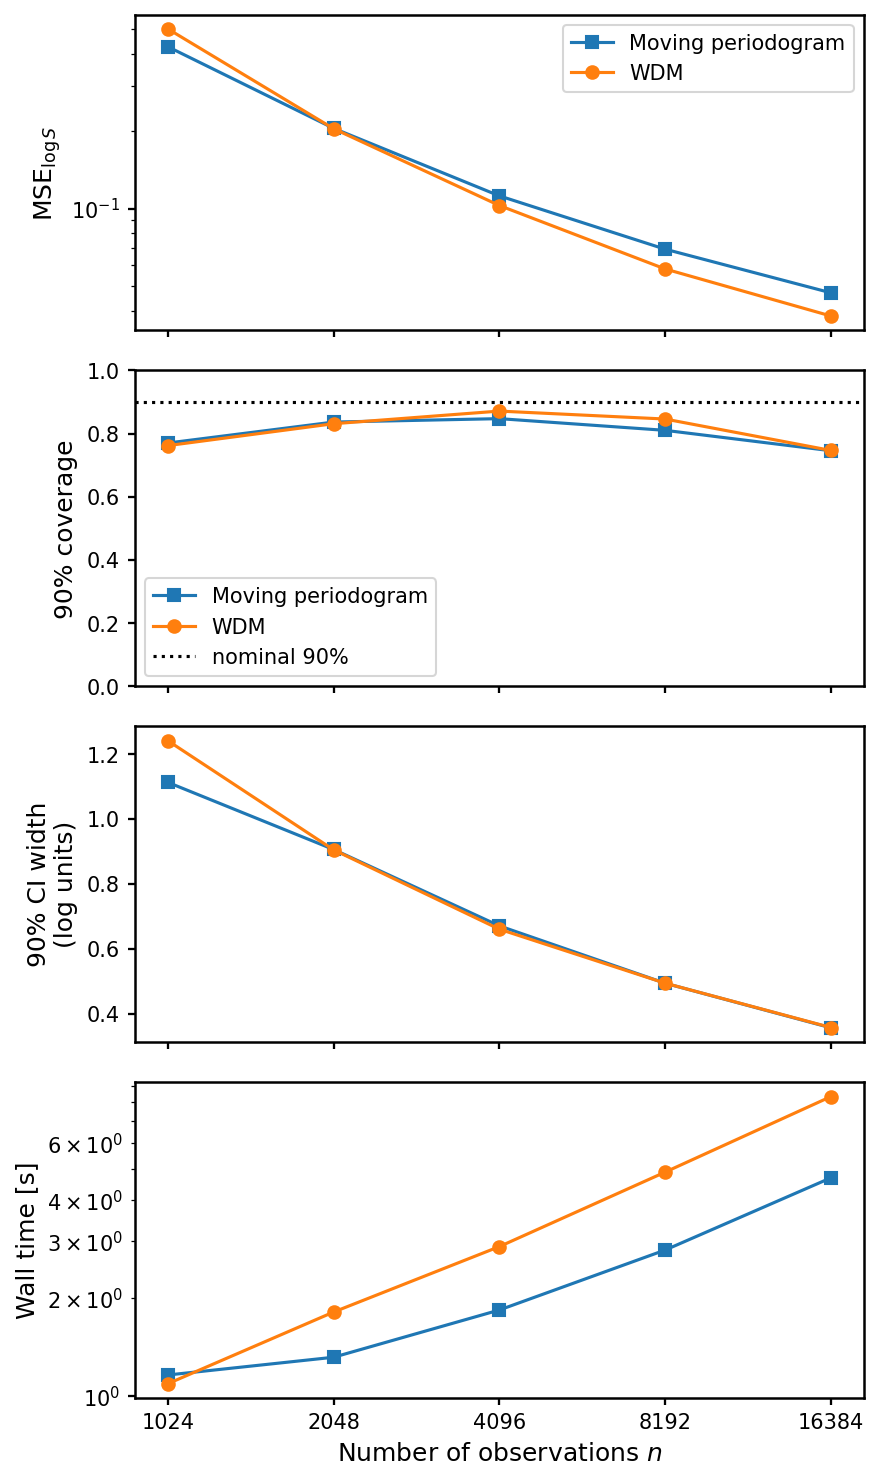

In [35]:
import pandas as pd

sweep_df = pd.DataFrame(sweep_records)

fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)
markers = {"WDM": "o", "Moving periodogram": "s"}
for method, group in sweep_df.groupby("method"):
    group = group.sort_values("n")
    kwargs = dict(marker=markers[method], label=method)
    axes[0].plot(group.n, group.mse, **kwargs)
    axes[1].plot(group.n, group.coverage, **kwargs)
    axes[2].plot(group.n, group.ci_width, **kwargs)
    axes[3].plot(group.n, group.wall_time, **kwargs)

axes[0].set_yscale("log")
axes[0].set_ylabel(r"MSE$_{\log S}$")
axes[0].legend()

axes[1].axhline(0.9, color="k", linestyle=":", label="nominal 90%")
axes[1].set_ylabel("90% coverage")
axes[1].set_ylim(0, 1)
axes[1].legend()

axes[2].set_ylabel("90% CI width\n(log units)")

axes[3].set_yscale("log")
axes[3].set_ylabel("Wall time [s]")
axes[3].set_xlabel("Number of observations $n$")
axes[3].set_xscale("log", base=2)
axes[3].set_xticks(n_values)
axes[3].set_xticklabels(n_values)

fig.tight_layout()
plt.show()

